In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [3]:
#Dataset Path
DATASET_PATH = r"C:\Users\lenovo\Desktop\garbageDS\dataset-resized"
IMG_SIZE = 224
BATCH_SIZE = 32

In [4]:
# Data augmentation and normalization
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
#LOad dataset and split into train/val
dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transforms)

class_names = dataset.classes
print("Classes:", class_names)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# IMPORTANT: apply validation transforms
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


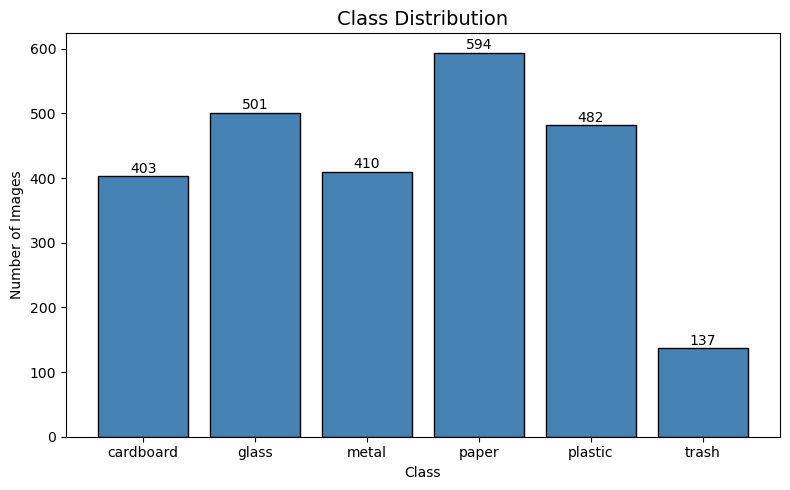

In [6]:
# Class Distribution Plot
import matplotlib.pyplot as plt

class_counts = [len([s for s in dataset.samples if s[1] == i]) for i in range(len(class_names))]

plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, class_counts, color='steelblue', edgecolor='black')
plt.title("Class Distribution", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# Calculate class weights to handle imbalance
targets = [label for _, label in dataset.samples]
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [8]:
# Load pre-trained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, len(class_names))
)

model = model.to(device)

c:\Users\lenovo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lenovo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# Training loop
def train_model(model, train_loader, val_loader, epochs):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs

In [11]:
# Train the model (phase 1)
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, epochs=5
)

Epoch 1: Train Acc=0.585, Val Acc=0.711
Epoch 2: Train Acc=0.760, Val Acc=0.810
Epoch 3: Train Acc=0.778, Val Acc=0.824
Epoch 4: Train Acc=0.813, Val Acc=0.830
Epoch 5: Train Acc=0.830, Val Acc=0.840


In [12]:
#fine-tuning phase 2
# Unfreeze last layers
for param in model.features[-4:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses_ft, val_losses_ft, train_accs_ft, val_accs_ft = train_model(
    model, train_loader, val_loader, epochs=5
)

Epoch 1: Train Acc=0.851, Val Acc=0.856
Epoch 2: Train Acc=0.934, Val Acc=0.885
Epoch 3: Train Acc=0.956, Val Acc=0.895
Epoch 4: Train Acc=0.958, Val Acc=0.899
Epoch 5: Train Acc=0.977, Val Acc=0.893


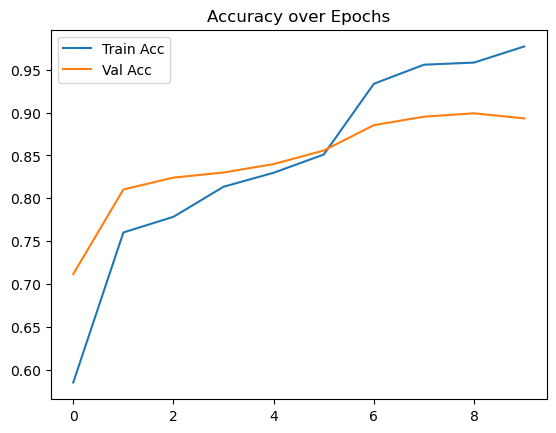

In [13]:
# Plotting training curve 
plt.plot(train_accs + train_accs_ft, label="Train Acc")
plt.plot(val_accs + val_accs_ft, label="Val Acc")
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()

🔹 Overall Metrics:
Accuracy : 0.8933
Precision: 0.8957
Recall   : 0.8933
F1 Score : 0.8935

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.90      0.92        68
       glass       0.93      0.85      0.89       102
       metal       0.84      0.95      0.90        85
       paper       0.92      0.94      0.93       128
     plastic       0.90      0.88      0.89        98
       trash       0.65      0.68      0.67        25

    accuracy                           0.89       506
   macro avg       0.87      0.87      0.87       506
weighted avg       0.90      0.89      0.89       506



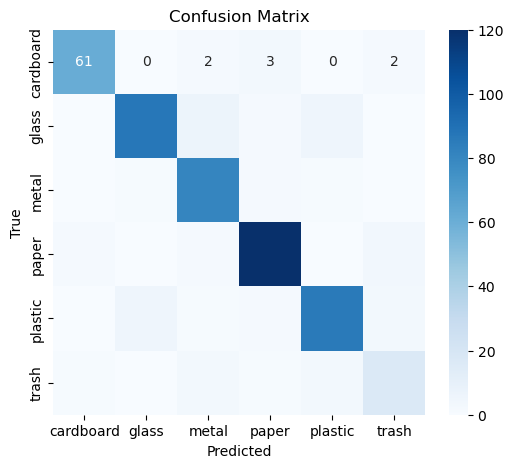

In [14]:
#Evaluation (Full Metrics + Confusion Matrix)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# ---- Core Metrics ----
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("🔹 Overall Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ---- Detailed Report ----
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [16]:
#save the model

torch.save(model.state_dict(), r"C:\Users\lenovo\Desktop\garbageDS\garbage_model.pth")

In [17]:
#presiction function

def predict_image_pytorch(img_path, model, class_names, transform):
    model.eval()
    
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
    
    probs = probs.cpu().numpy()[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]

    conf_dict = {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    
    return pred_class, conf_dict

In [18]:
#GUI (Adapted for PyTorch)

import tkinter as tk
from tkinter import filedialog, messagebox, ttk
from PIL import Image, ImageTk

class GarbageClassifierApp:
    def __init__(self, root, model, class_names, transform):
        self.root = root
        self.model = model
        self.class_names = class_names
        self.transform = transform

        root.title("Garbage Classifier (DL)")
        root.resizable(False, False)
        root.configure(bg="#f0f0f0")

        tk.Label(root, text="🗑 Garbage Classifier",
                 font=("Helvetica", 16, "bold"), bg="#f0f0f0").pack(pady=(16, 2))

        self.img_label = tk.Label(root, bg="#ddd", width=40, height=14,
                                  text="No image loaded", relief="sunken")
        self.img_label.pack(padx=20, pady=12)

        btn_frame = tk.Frame(root, bg="#f0f0f0")
        btn_frame.pack(pady=4)

        tk.Button(btn_frame, text="📂 Open Image", width=16,
                  command=self.open_image).pack(side=tk.LEFT, padx=6)

        tk.Button(btn_frame, text="🔍 Classify", width=16,
                  command=self.classify).pack(side=tk.LEFT, padx=6)

        self.result_var = tk.StringVar(value="—")
        tk.Label(root, text="Prediction:", font=("Helvetica", 10, "bold"),
                 bg="#f0f0f0").pack(pady=(10, 0))
        tk.Label(root, textvariable=self.result_var,
                 font=("Helvetica", 14), fg="#1a6fc4", bg="#f0f0f0").pack()

        self.bar_frame = tk.Frame(root, bg="#f0f0f0")
        self.bar_frame.pack(padx=24, pady=(4, 16), fill=tk.X)

        self.bars = {}
        for cls in self.class_names:
            row = tk.Frame(self.bar_frame, bg="#f0f0f0")
            row.pack(fill=tk.X, pady=2)

            tk.Label(row, text=f"{cls:10s}", width=11, anchor='w',
                     font=("Courier", 9), bg="#f0f0f0").pack(side=tk.LEFT)

            bar = ttk.Progressbar(row, length=200, maximum=100)
            bar.pack(side=tk.LEFT, padx=4)

            pct_lbl = tk.Label(row, text="0.0%", width=6,
                               font=("Courier", 9), bg="#f0f0f0")
            pct_lbl.pack(side=tk.LEFT)

            self.bars[cls] = (bar, pct_lbl)

        self.img_path = None

    def open_image(self):
        path = filedialog.askopenfilename(
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")]
        )
        if not path:
            return

        self.img_path = path
        self.result_var.set("—")
        self._reset_bars()

        img = Image.open(path).resize((280, 200))
        photo = ImageTk.PhotoImage(img)

        self.img_label.configure(image=photo, text="")
        self.img_label.image = photo

    def classify(self):
        if not self.img_path:
            messagebox.showwarning("No image", "Please open an image first.")
            return

        try:
            pred, conf = predict_image_pytorch(
                self.img_path, self.model,
                self.class_names, self.transform
            )

            self.result_var.set(pred.upper())

            for cls, (bar, lbl) in self.bars.items():
                pct = conf.get(cls, 0.0) * 100
                bar["value"] = pct
                lbl.config(text=f"{pct:.1f}%")

        except Exception as e:
            messagebox.showerror("Error", str(e))

    def _reset_bars(self):
        for bar, lbl in self.bars.values():
            bar["value"] = 0
            lbl.config(text="0.0%")

In [ ]:
#load mmodel + un GUI 

model = models.mobilenet_v2(pretrained=False)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, len(class_names))
)

model.load_state_dict(torch.load(r"C:\Users\lenovo\Desktop\garbageDS\garbage_model.pth", map_location=device))
model = model.to(device)

# IMPORTANT: use validation transforms (NO augmentation)
transform = val_transforms

root = tk.Tk()
app = GarbageClassifierApp(root, model, class_names, transform)
root.mainloop()

In [ ]:
# Load Model + Run GUI (Standalone)

device = torch.device("cpu")

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']  

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

model = models.mobilenet_v2(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, len(class_names))
)

torch.load(r"C:\Users\lenovo\Desktop\garbageDS\garbage_model.pth", map_location=device)
model = model.to(device)

root = tk.Tk()
app = GarbageClassifierApp(root, model, class_names, val_transforms)
root.mainloop()

In [ ]:
import os
print(os.getcwd())

c:\Users\lenovo\Desktop
